### Alarm Log Cleaning

The following preprocessing steps were performed:

1. Loaded raw alarm log data
2. Select relevant columns
3. Replace \N with NA
4. Convert timestamps to datetime format
5. Check missing values
6. Check duplicates
7. Exported the cleaned dataset

In [158]:
# import all the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt


In [159]:
# load the data
df_alarm= pd.read_excel(r"E:\Uis Cs\Master thesis\final_project\data\alarmlogg\raw_data\Alarmlogg\Øgreyfoss Alarmlogg.xlsx")

In [84]:
# Shows the more details about the alarm log dataset before cleaning  

df_alarm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ACK_TS          100000 non-null  object
 1   ALARMDESC       100000 non-null  object
 2   CATEGORY        100000 non-null  object
 3   id              100000 non-null  int64 
 4   INCLUDE_REPORT  100000 non-null  int64 
 5   LOCATION        99926 non-null   object
 6   OFF_TS          100000 non-null  object
 7   ON_TS           100000 non-null  object
 8   refAlarm        100000 non-null  object
 9   SOURCE          100000 non-null  object
 10  SUMSTATE        100000 non-null  object
 11  TAG             100000 non-null  object
 12  TYPE            100000 non-null  object
 13  USER_COMMENT    60683 non-null   object
 14  StationName     100000 non-null  object
dtypes: int64(2), object(13)
memory usage: 11.4+ MB


In [139]:
df_alarm.head(5)   # shows the first 5 rows of dataset 

,ACK_TS,ALARMDESC,CATEGORY,id,INCLUDE_REPORT,LOCATION,OFF_TS,ON_TS,refAlarm,SOURCE,SUMSTATE,TAG,TYPE,USER_COMMENT,StationName
0,2021-01-05 12:30:39,"Mobilradio (4G) signalstyrke - Høy-høy alarm, 31",\N,2750460,1,NaN,2021-01-05 12:30:39,\N,\N,CITECT1,OFF:ACK,OGREY1_BILSTDVT_KONTROLL_SIGSTYRK_HH_AL,Advanced,\N,OGREY1
1,2021-01-05 12:30:39,"Mobilradio (4G) signalstyrke - Høy alarm, 31",\N,2750467,1,NaN,2021-01-05 12:30:39,\N,\N,CITECT1,OFF:ACK,OGREY1_BILSTDVT_KONTROLL_SIGSTYRK_H_AL,Advanced,\N,OGREY1
2,2021-01-05 12:30:39,"Total vannføring vassdrag - Høy-høy alarm, 6,...",\N,2750451,1,NaN,2021-01-05 12:30:39,\N,17252,CITECT1,OFF:ACK,OGREY1_BILSTDVT_KONTROLL_TOT_VF_HH_AL,Advanced,\N,OGREY1
3,2021-01-05 12:30:33,"Total vannføring vassdrag - Høy alarm, 6,03 m3/s",\N,2750450,1,NaN,2021-01-05 12:30:33,\N,17254,CITECT1,OFF:ACK,OGREY1_BILSTDVT_KONTROLL_TOT_VF_H_AL,Advanced,\N,OGREY1
4,2021-01-05 12:30:39,"Nivåmåling primærsensor HRV - Høy-høy alarm, 1...",\N,2750462,1,NaN,2021-01-05 12:30:39,\N,\N,CITECT1,OFF:ACK,OGREY1_BILSTDVT_NIVA_SENSOR_PRI_HRV_HH_AL,Advanced,\N,OGREY1


The dataset contained 15 columns. Only the columns relevant to alarm analysis and label generation were selected: ACK_TS, ON_TS, OFF_TS, CATEGORY,id, TAG, and ALARMDESC

In [161]:
filter_data=df_alarm[['ACK_TS', 'ALARMDESC','CATEGORY','id','TAG','ON_TS','OFF_TS']].copy()

In [162]:
# get the more information about the dataset ( feature names, missing value count and data type)
filter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ACK_TS     100000 non-null  object
 1   ALARMDESC  100000 non-null  object
 2   CATEGORY   100000 non-null  object
 3   id         100000 non-null  int64 
 4   TAG        100000 non-null  object
 5   ON_TS      100000 non-null  object
 6   OFF_TS     100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [163]:
# dataset used \N as a missing value indicator. Pandas does not count \N as missing (NaN)

for col in filter_data.columns:
    print(col, (filter_data[col].astype(str).str.strip() == r'\N').sum())

ACK_TS 67290
ALARMDESC 0
CATEGORY 55
id 0
TAG 0
ON_TS 55
OFF_TS 19


In [164]:
# Number of unique tags in dataset
filter_data['TAG'].nunique()

181

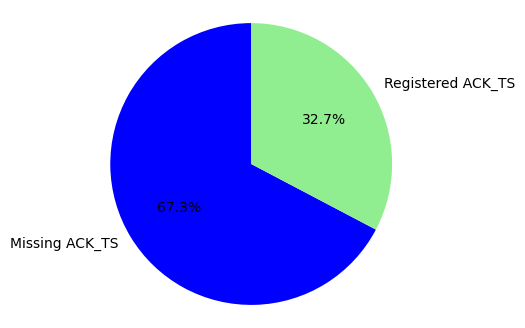

In [165]:
# This plot shows the procent of missing valuse in ACK_TS columns 
ts_status = filter_data["ACK_TS"].apply(lambda x: "Missing ACK_TS" if x == "\\N" else "Registered ACK_TS")

# Count values
counts = ts_status.value_counts()

# Pie chart
plt.figure(figsize=(4,4))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=['blue', 'lightgreen'],
    startangle=90
)

plt.axis('equal')

plt.show()

In [169]:
# Invalid values represented by \N were replaced with standard missing values (NA) 
# Convert CATEGORY to nullable integer
## The timestamp columns (ACK_TS, ON_TS, and OFF_TS) were converted from object data type to datetime format

filter_data = filter_data.replace(r'\N', pd.NA)

filter_data['CATEGORY'] = filter_data['CATEGORY'].astype('Int64')

filter_data['ACK_TS'] = pd.to_datetime(filter_data['ACK_TS'], errors='coerce')
filter_data['ON_TS'] = pd.to_datetime(filter_data['ON_TS'], errors='coerce')
filter_data['OFF_TS'] = pd.to_datetime(filter_data['OFF_TS'], errors='coerce')

filter_data[['ACK_TS', 'ON_TS', 'OFF_TS']].dtypes


ACK_TS    datetime64[ns]
ON_TS     datetime64[ns]
OFF_TS    datetime64[ns]
dtype: object

In [171]:
## check for missing values

filter_data.isnull().sum()

ACK_TS       67290
ALARMDESC        0
CATEGORY        55
id               0
TAG              0
ON_TS           55
OFF_TS          19
dtype: int64

In [172]:
# This shows the time period covered by the dataset

print("Min:", filter_data['ACK_TS'].min(), "| Max:", filter_data['ACK_TS'].max())


Min: 2020-12-02 11:22:58 | Max: 2026-01-15 05:56:36


In [173]:
# Check for duplicate rows and columns

duplicate_rows = filter_data.duplicated().sum()
duplicate_collumns = filter_data.T.duplicated().sum()
print("Duplciate rows: ", duplicate_rows)
print("Duplicate columns: ", duplicate_collumns)

Duplciate rows:  0
Duplicate columns:  0


In [174]:
filter_data['CATEGORY'].value_counts(dropna=False)

CATEGORY
3       84603
2       11042
1        4208
4          92
<NA>       55
Name: count, dtype: Int64

In [175]:
# Descriptive statistics over the cleaned data: 
# count: shows the number of non missing values
#The timestamps span roughly from December 2020 to January 2026

filter_data.describe()

,ACK_TS,CATEGORY,id,ON_TS,OFF_TS
count,32710,99945.0,1.000000e+05,99945,99981
mean,2023-11-10 06:30:59.696422912,2.806233,3.490691e+06,2023-01-03 07:25:49.014338048,2023-01-03 03:24:59.445474560
min,2020-12-02 11:22:58,1.0,2.723774e+06,2020-12-02 11:22:58,2020-12-02 11:22:58
25%,2022-10-10 04:52:16,3.0,2.920630e+06,2021-08-08 23:43:41,2021-08-08 23:30:08
50%,2024-05-09 08:53:28.500000,3.0,3.373729e+06,2022-11-04 13:24:42,2022-11-04 17:32:28
75%,2025-01-27 00:00:54.750000128,3.0,4.008148e+06,2024-03-17 19:50:21,2024-03-17 19:50:20
max,2026-01-15 05:56:36,4.0,4.633194e+06,2026-01-15 05:56:36,2026-01-15 06:23:16
std,NaN,0.49221,6.053688e+05,NaN,NaN


In [134]:
# Save cleaned dataset

clean_alarms.to_csv(r"E:\Uis Cs\Master thesis\final_project\data\alarmlogg\clean_alarm_data.csv", index=False)


The dataset was cleaned by handling invalid values, converting timestamp fields to datetime format. A large number of missing values were identified in the dataset, special in the ACK_TS column. These records were not removed because they still contained useful information for other analysis tasks. Instead, only the records required for a specific analysis were selected when needed.

